In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
rf_model  = joblib.load("/Users/saif/Desktop/ML_Load_Forecasting/models/rf_tuned.pkl")
xgb_model = joblib.load("/Users/saif/Desktop/ML_Load_Forecasting/models/xgb_tuned.pkl")


df = pd.read_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Gold/df_features_fourier_time_encoding.csv", 
                  index_col=0, parse_dates=True)
df.columns = df.columns.str.strip()

In [8]:
X = df.drop(columns=["Load_MW"])
y = df["Load_MW"]

X_train = X[X.index.year < 2023]
X_test  = X[X.index.year == 2023]
y_train = y[y.index.year < 2023]
y_test  = y[y.index.year == 2023]

print(X_test.shape)
print(y_test.shape)

print(X_train.shape)

(8592, 21)
(8592,)
(26137, 21)


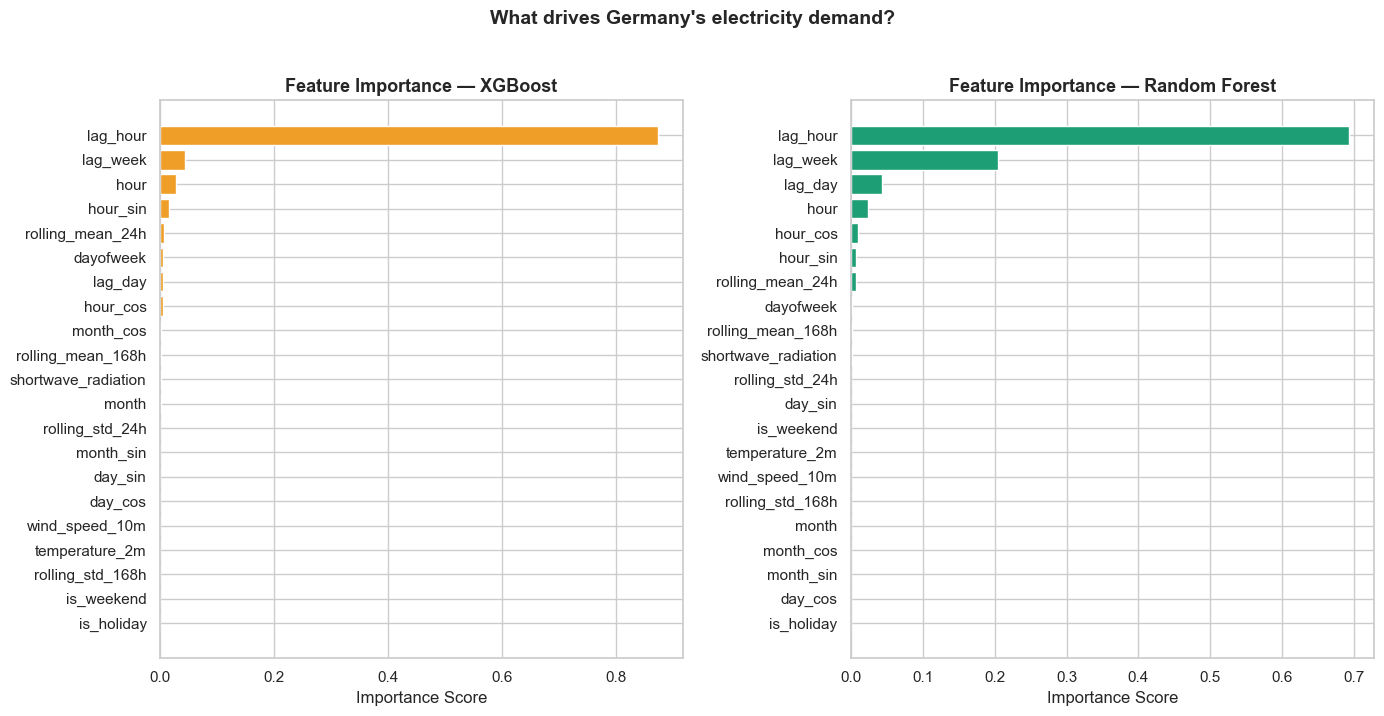

In [6]:
sns.set_theme(style="whitegrid")

feature_names = X_train.columns.tolist()

# XGBoost
importance_xgb = xgb_model.feature_importances_
df_imp_xgb = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": importance_xgb
}).sort_values("Importance", ascending=True)

# Random Forest
importance_rf = rf_model.feature_importances_
df_imp_rf = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": importance_rf
}).sort_values("Importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(df_imp_xgb["Feature"],
             df_imp_xgb["Importance"],
             color="#EF9F27")
axes[0].set_title("Feature Importance — XGBoost",
                   fontsize=13, fontweight="bold")
axes[0].set_xlabel("Importance Score")

axes[1].barh(df_imp_rf["Feature"],
             df_imp_rf["Importance"],
             color="#1D9E75")
axes[1].set_title("Feature Importance — Random Forest",
                   fontsize=13, fontweight="bold")
axes[1].set_xlabel("Importance Score")

plt.suptitle("What drives Germany's electricity demand?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/10_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

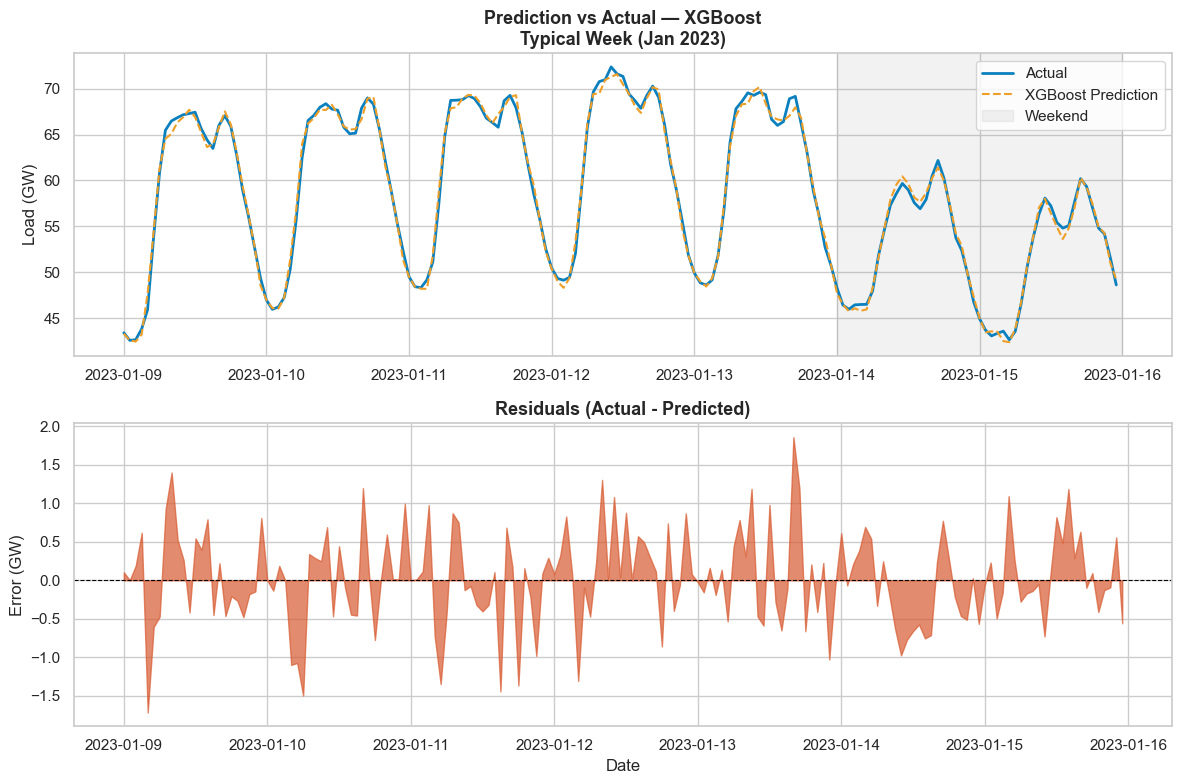

In [9]:
sns.set_theme(style="whitegrid")

# Eine typische Woche aus 2023 nehmen
week_start = "2023-01-09"
week_end   = "2023-01-15"

# XGBoost Vorhersagen für gesamten Testdatensatz
y_pred_xgb = xgb_model.predict(X_test)

# Als Series mit Index
y_pred_series = pd.Series(y_pred_xgb, index=X_test.index)
y_test_series = pd.Series(y_test.values, index=X_test.index)

# Eine Woche filtern
y_actual_week = y_test_series.loc[week_start:week_end] / 1000
y_pred_week   = y_pred_series.loc[week_start:week_end] / 1000

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1 — Prediction vs Actual
axes[0].plot(y_actual_week.index, y_actual_week.values,
             label="Actual", color="#0B80BE", linewidth=2)
axes[0].plot(y_pred_week.index, y_pred_week.values,
             label="XGBoost Prediction", color="#EF9F27",
             linewidth=1.5, linestyle="--")

# Wochenende markieren
axes[0].axvspan("2023-01-14", "2023-01-16",
                alpha=0.1, color="gray", label="Weekend")

axes[0].set_title("Prediction vs Actual — XGBoost\nTypical Week (Jan 2023)",
                   fontsize=13, fontweight="bold")
axes[0].set_ylabel("Load (GW)")
axes[0].legend()

# Plot 2 — Residuals (Fehler)
residuals = y_actual_week - y_pred_week

axes[1].fill_between(residuals.index, residuals.values,
                      alpha=0.7, color="#D85A30")
axes[1].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Residuals (Actual - Predicted)",
                   fontsize=13, fontweight="bold")
axes[1].set_ylabel("Error (GW)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/11_prediction_vs_actual.png",
            dpi=150, bbox_inches="tight")
plt.show()